In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hour = pd.read_csv("hour.csv")
day = pd.read_csv("day.csv")

In [6]:
hour = hour.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
day = day.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
print("Hour dataset after dropping columns:")
print(hour.head().to_string(index=False))

print("\nDay dataset after dropping columns:")
print(day.head().to_string(index=False))


Hour dataset after dropping columns:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1

Day dataset after dropping columns:
 season  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  cnt
      1     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446  985
      1     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539  801
      1     1        0        1           1           1 0.196364 

In [7]:
hour.isnull().sum()



season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [8]:
day.isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [9]:
hour_duplicates = hour.duplicated().sum()
day_duplicates = day.duplicated().sum()
print("Number of duplicate hours:", hour_duplicates)
print("Number of duplicate days:", day_duplicates)




Number of duplicate hours: 2
Number of duplicate days: 0


In [10]:
hour = hour.drop_duplicates() 
print("Hour dataset after dropping duplicates:")
print(hour.head().to_string(index=False))


Hour dataset after dropping duplicates:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1


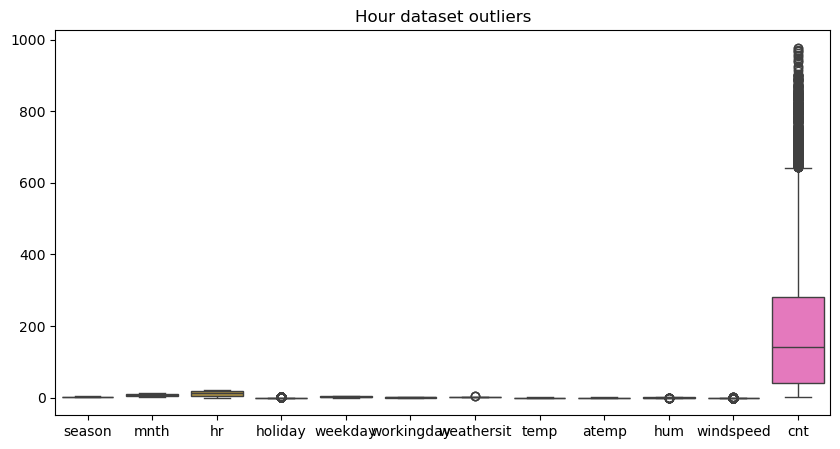

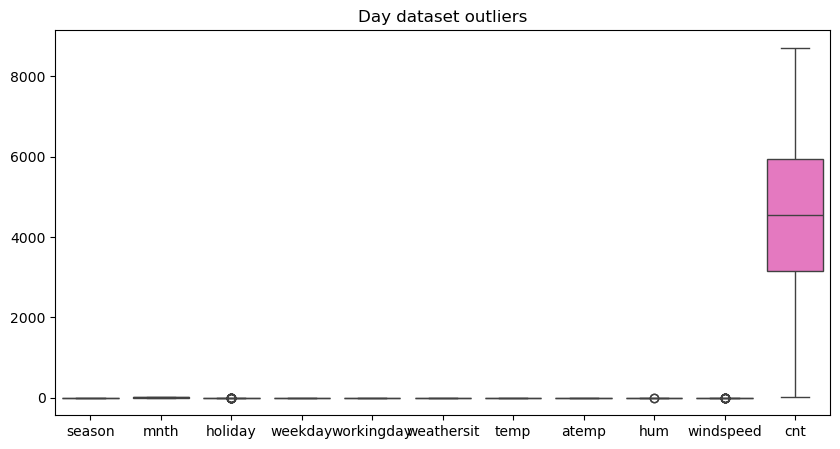

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=hour)
plt.title("Hour dataset outliers")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=day)
plt.title("Day dataset outliers")
plt.show()


In [12]:
# ---- Outlier Detection for Hour Data ----
Q1_hr = hour.quantile(0.25)
Q3_hr = hour.quantile(0.75)
IQR_hr = Q3_hr - Q1_hr

lower_limit_hr = Q1_hr - 1.5 * IQR_hr
upper_limit_hr = Q3_hr + 1.5 * IQR_hr

hour_cleaned = hour[~((hour < lower_limit_hr) | (hour > upper_limit_hr)).any(axis=1)]

print("Original Hour Shape:", hour.shape)
print("After Removing Outliers:", hour_cleaned.shape)

Original Hour Shape: (17377, 12)
After Removing Outliers: (16027, 12)


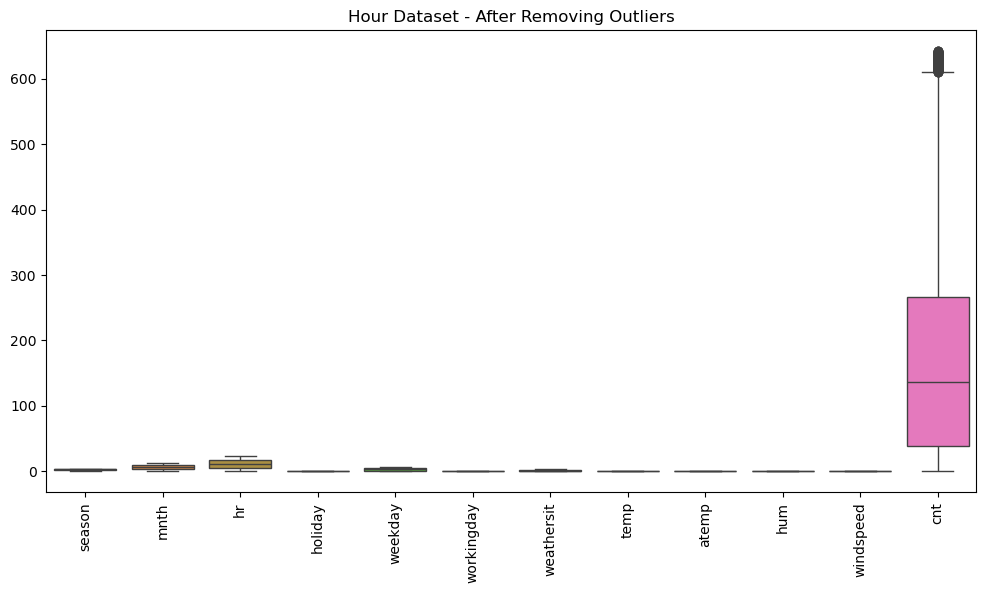

In [13]:
# ---- Boxplot after removing outliers ----
plt.figure(figsize=(12,6))
sns.boxplot(data=hour_cleaned)
plt.title("Hour Dataset - After Removing Outliers")
plt.xticks(rotation=90)
plt.show()

In [14]:
# ---- Outlier Detection for Day Data ----
Q1 = day.quantile(0.25)
Q3 = day.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

day_cleaned = day[~((day < lower_limit) | (day > upper_limit)).any(axis=1)]
print("Original Day Shape:", day.shape)
print("After Removing Outliers:", day_cleaned.shape)



Original Day Shape: (731, 11)
After Removing Outliers: (696, 11)


In [15]:
print("Null values per column (Hourly):")
print(hour.isnull().sum())

print("\nNull values per column (Daily):")
print(day.isnull().sum())

hour = hour.fillna(hour.median())
day = day.fillna(day.median())

print("After filling, nulls (Hourly):", hour.isnull().sum().sum())
print("After filling, nulls (Daily):", day.isnull().sum().sum())

Null values per column (Hourly):
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Null values per column (Daily):
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
After filling, nulls (Hourly): 0
After filling, nulls (Daily): 0


In [16]:
X_hour = hour.drop("cnt", axis=1)
y_hour = hour["cnt"]

X_day = day.drop("cnt", axis=1)
y_day = day["cnt"]

In [17]:
from sklearn.model_selection import train_test_split

# Hourly data train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(X_hour, y_hour, test_size=0.2, random_state=42)
# Daily data train-test split
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

In [18]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_evaluate_rf(X_train, X_test, y_train, y_test, dataset_name="Dataset"):
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    
    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
     
    print(f"{dataset_name} - Random Forest Metrics")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")
    return rf 
    


In [19]:
#Train & evaluate for both datasets
rf_hour = train_evaluate_rf(X_train_hr, X_test_hr, y_train_hr, y_test_hr, "Hourly Data")
rf_day  = train_evaluate_rf(X_train_day, X_test_day, y_train_day, y_test_day, "Daily Data")


Hourly Data - Random Forest Metrics
MAE: 42.88, RMSE: 64.90, R²: 0.86

Daily Data - Random Forest Metrics
MAE: 1083.93, RMSE: 1305.34, R²: 0.58



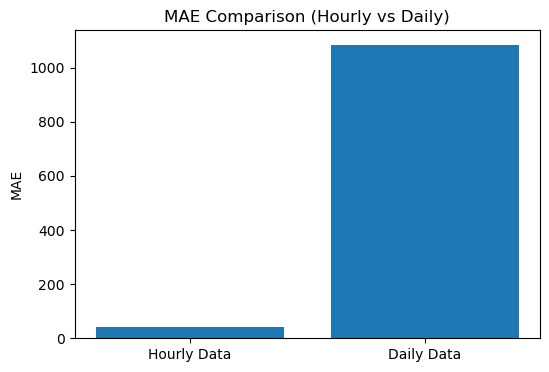

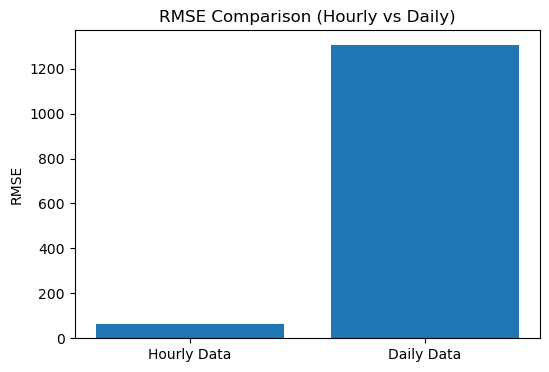

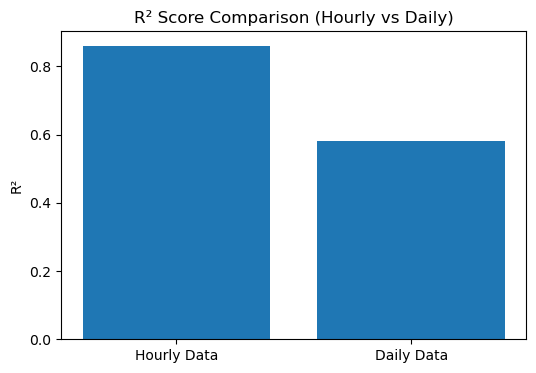

In [20]:
# ---- Metrics Comparison Graphs ----

import matplotlib.pyplot as plt

datasets = ["Hourly Data", "Daily Data"]
mae_values = [42.88, 1083.93]
rmse_values = [64.90, 1305.34]
r2_values = [0.86, 0.58]


# MAE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, mae_values)
plt.title("MAE Comparison (Hourly vs Daily)")
plt.ylabel("MAE")
plt.show()

# RMSE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, rmse_values)
plt.title("RMSE Comparison (Hourly vs Daily)")
plt.ylabel("RMSE")
plt.show()

# R² Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, r2_values)
plt.title("R² Score Comparison (Hourly vs Daily)")
plt.ylabel("R²")
plt.show()


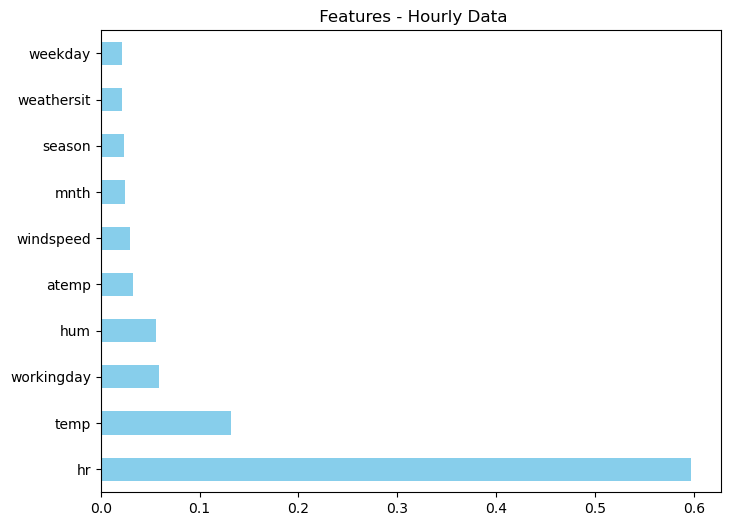

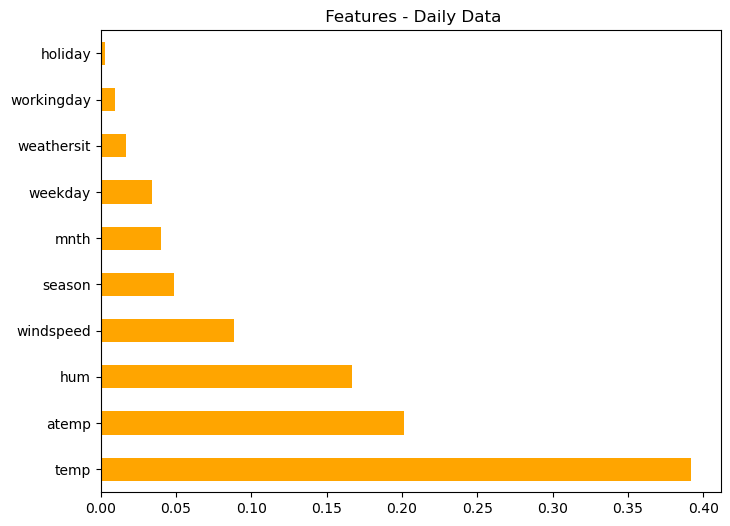

In [21]:
               # --- Feature Importance Plot ---
def plot_feature_importance(rf_model, X_train, dataset_name):
    feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    plt.figure(figsize=(8,6))
    color = 'skyblue' if dataset_name=="Hourly Data" else 'orange'
    feat_importances.nlargest(10).plot(kind='barh', color=color)
    plt.title(f" Features - {dataset_name}")
    plt.show()

# Plot top 10 features for both datasets
plot_feature_importance(rf_hour, X_train_hr, "Hourly Data")
plot_feature_importance(rf_day, X_train_day, "Daily Data")

In [22]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
X_hour = hour.drop('cnt', axis=1)
y_hour = hour['cnt']

X_day = day.drop('cnt', axis=1)
y_day = day['cnt']


In [24]:
# Train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(X_hour, y_hour, test_size=0.2, random_state=42)
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)
print("Hourly Train Shape:", X_train_hr.shape, "Test Shape:", X_test_hr.shape)
print("Daily Train Shape:", X_train_day.shape, "Test Shape:", X_test_day.shape)


Hourly Train Shape: (13901, 11) Test Shape: (3476, 11)
Daily Train Shape: (584, 10) Test Shape: (147, 10)


In [25]:

#Train & Evaluate Multiple Models
def train_evaluate_models(X_train, X_test, y_train, y_test, dataset_name="Dataset"):
    models = {
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        print(f"{dataset_name} - {name}")
        print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")
    return results

# Hourly Data
print("----- Hourly Data -----")
results_hr = train_evaluate_models(X_train_hr, X_test_hr, y_train_hr, y_test_hr, "Hourly Data")

# Daily Data
print("----- Daily Data -----")
results_day = train_evaluate_models(X_train_day, X_test_day, y_train_day, y_test_day, "Daily Data")


----- Hourly Data -----
Hourly Data - Linear Regression
MAE: 105.72, RMSE: 141.70, R²: 0.35

Hourly Data - Decision Tree
MAE: 53.94, RMSE: 88.59, R²: 0.74

Hourly Data - Random Forest
MAE: 42.88, RMSE: 64.90, R²: 0.86

----- Daily Data -----
Daily Data - Linear Regression
MAE: 1143.39, RMSE: 1340.51, R²: 0.55

Daily Data - Decision Tree
MAE: 1248.16, RMSE: 1644.85, R²: 0.33

Daily Data - Random Forest
MAE: 1083.93, RMSE: 1305.34, R²: 0.58



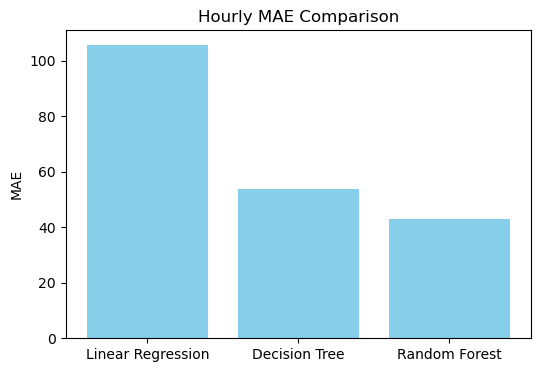

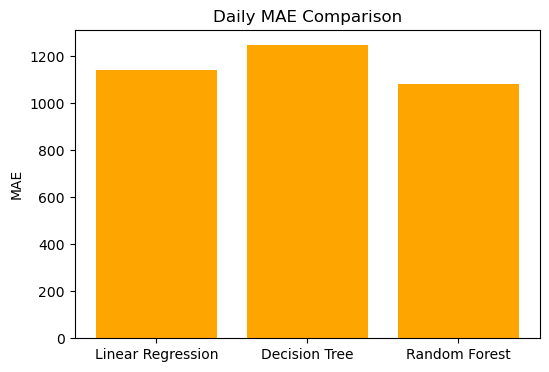

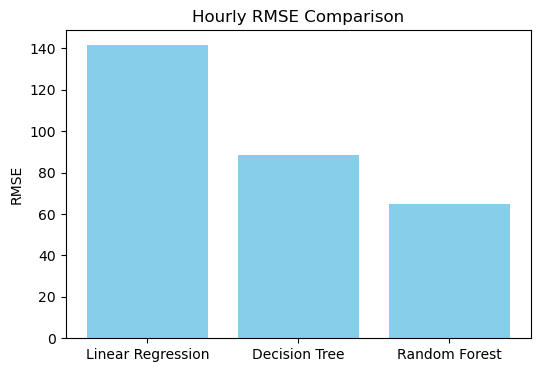

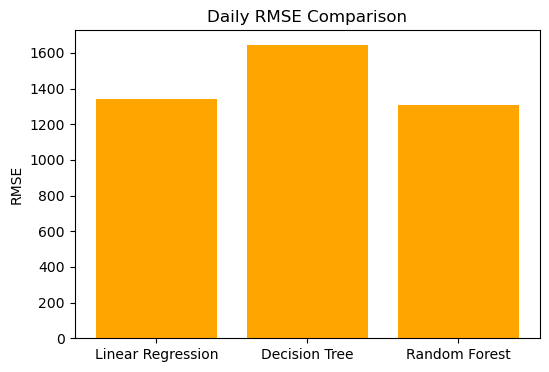

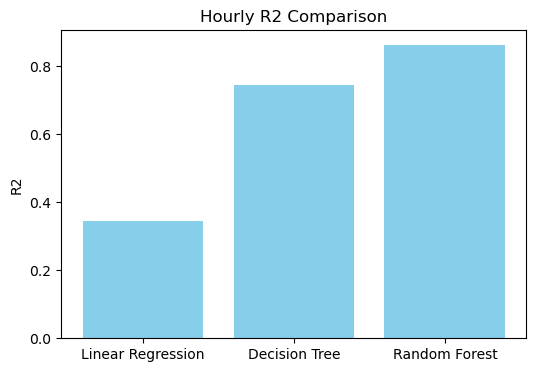

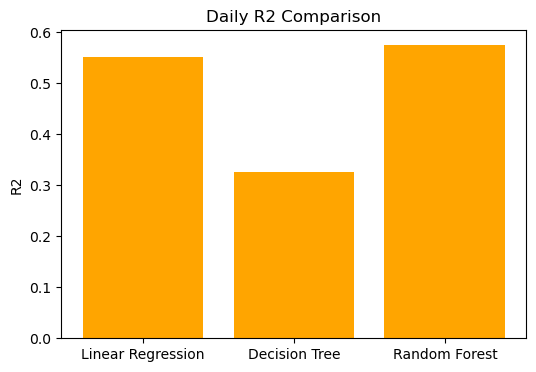

In [26]:
 hour_results = pd.DataFrame(results_hr).T.reset_index().rename(columns={'index':'Model'})
day_results = pd.DataFrame(results_day).T.reset_index().rename(columns={'index':'Model'})  
metrics = ['MAE', 'RMSE', 'R2']
colors = {'Hourly':'skyblue','Daily':'orange'}

for metric in metrics:
    # Hourly
    plt.figure(figsize=(6,4))
    plt.bar(hour_results["Model"], hour_results[metric], color=colors['Hourly'])
    plt.title(f"Hourly {metric} Comparison")
    plt.ylabel(metric)
    plt.show()
    
    # Daily
    plt.figure(figsize=(6,4))
    plt.bar(day_results["Model"], day_results[metric], color=colors['Daily'])
    plt.title(f"Daily {metric} Comparison")
    plt.ylabel(metric)
    plt.show()

In [36]:
# Hyperparameter Tuning (Random Forest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, ]
}

# Hourly
grid_hr = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_hr.fit(X_train_hr, y_train_hr)
best_rf_hr = grid_hr.best_estimator_
print("Hourly Best RF Params:", grid_hr.best_params_)

# Daily
grid_day = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_day.fit(X_train_day, y_train_day)
best_rf_day = grid_day.best_estimator_
print("Daily Best RF Params:", grid_day.best_params_)

Hourly Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Daily Best RF Params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [37]:
#Evaluate Best Random Forest
def evaluate_best_model(model, X_test, y_test, dataset_name="Dataset"):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{dataset_name} - Best Random Forest Evaluation")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}\n") 
    return y_pred
# Evaluate Hourly Best Random Forest
y_pred_hr = evaluate_best_model(best_rf_hr, X_test_hr, y_test_hr, "Hourly Data")
# Evaluate Daily Best Random Forest
y_pred_day = evaluate_best_model(best_rf_day, X_test_day, y_test_day, "Daily Data")

Hourly Data - Best Random Forest Evaluation
MAE: 42.68
RMSE: 64.45
R² Score: 0.86

Daily Data - Best Random Forest Evaluation
MAE: 1081.86
RMSE: 1298.00
R² Score: 0.58



In [122]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


In [123]:
print(day.columns)


Index(['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')


In [124]:
#Separate features and target
# Hourly
X_hour = hour.drop('cnt', axis=1)
y_hour = hour['cnt']

X_day = day.drop('cnt', axis=1)
y_day = day['cnt']


In [125]:
# Standardize numeric features for neural network
scaler = StandardScaler()
X_day_scaled = scaler.fit_transform(X_day)

In [126]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_day_scaled, y_day, test_size=0.2, random_state=42
)

In [127]:
# Neural Network
mlp_day= MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,              
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
mlp.fit(X_train, y_train)


MLPRegressor(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
             max_iter=1000, n_iter_no_change=20, random_state=42)

In [128]:
# Evaluation
y_pred = mlp.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Neural Network – Daily Data")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Neural Network – Daily Data
MAE  : 1077.80
RMSE : 1285.14
R²   : 0.59


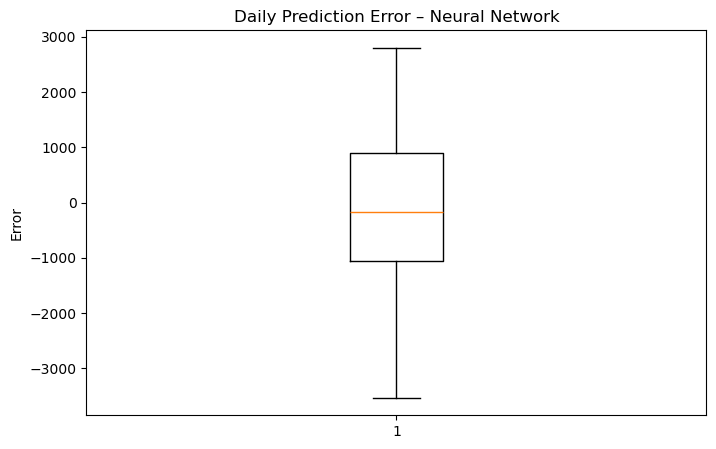

In [129]:
#ERROR BOXPLOT
errors_day = y_test_day - y_pred_day
plt.figure(figsize=(8,5))
plt.boxplot(errors_day)
plt.title("Daily Prediction Error – Neural Network")
plt.ylabel("Error")
plt.show()

In [130]:

X_latest_hour = X_hour.iloc[-1:].copy()
X_latest_day = X_day.iloc[-1:].copy()

In [136]:
# HOUR+1 → HOUR+6 PREDICTION
hour_predictions = []

for i in range(6):  # 6 future hours
    pred = rf_hour.predict(X_latest_hour)[0]
    hour_predictions.append(pred)
    if 'hr' in X_latest_hour.columns:
        X_latest_hour['hr'] = (X_latest_hour['hr'] + 1) % 24
print("Hourly Predictions (Hour → Hour+6):")
for i, val in enumerate(hour_predictions):
    print(f"Hour+{i+1}: {val:.2f}")



Hourly Predictions (Hour → Hour+6):
Hour+1: 14.91
Hour+2: 36.92
Hour+3: 135.56
Hour+4: 239.47
Hour+5: 168.21
Hour+6: 115.82


In [139]:

# Latest row
X_latest_day = X_test_day.iloc[-1:].copy()
X_latest_day_scaled = scaler_day.transform(X_latest_day)

# Predict next 6 days
day_predictions = []
for i in range(6):
    pred = mlp_day.predict(X_latest_day_scaled)[0]
    day_predictions.append(pred)
    
    # Increment day feature if exists
    if 'day_count' in X_latest_day.columns:
        X_latest_day['day_count'] += 1
        X_latest_day_scaled = scaler_day.transform(X_latest_day)

# Print vertically
for i, val in enumerate(day_predictions):
    print(f"Day+{i+1}: {val:.2f}")
   



Day+1: 5157.70
Day+2: 5157.70
Day+3: 5157.70
Day+4: 5157.70
Day+5: 5157.70
Day+6: 5157.70


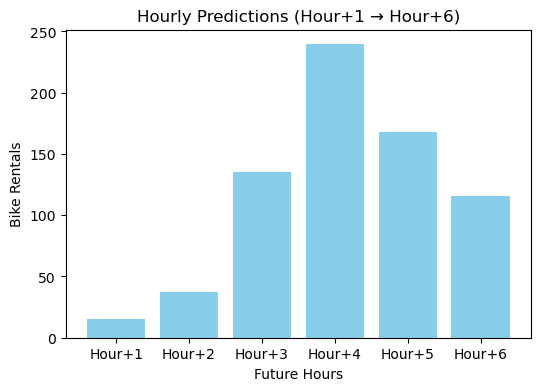

In [140]:
# Hourly Predictions Graph
hours = [f"Hour+{i+1}" for i in range(6)]
plt.figure(figsize=(6,4))
plt.bar(hours, hour_predictions, color='skyblue')
plt.title("Hourly Predictions (Hour+1 → Hour+6)")
plt.ylabel("Bike Rentals")
plt.xlabel("Future Hours")
plt.show()

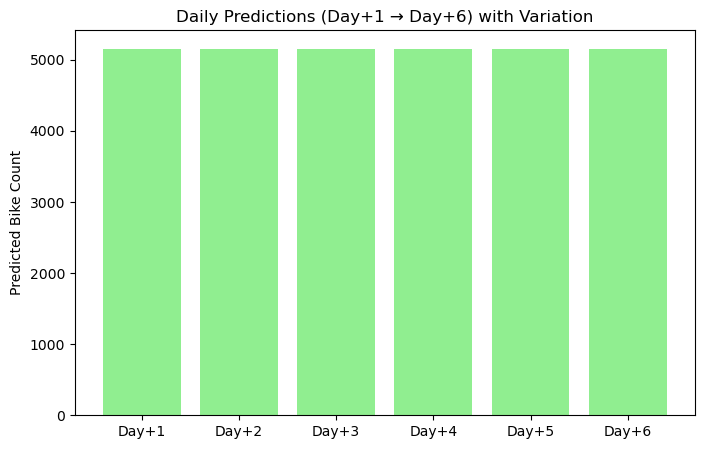

In [144]:
# Daily Predictions Graph
days = [f"Day+{i+1}" for i in range(6)]
plt.figure(figsize=(8,5))
plt.bar(days, day_predictions, color='lightgreen')
plt.title("Daily Predictions (Day+1 → Day+6) with Variation")
plt.ylabel("Predicted Bike Count")
plt.show()
